In [ ]:
!pip install transformers gensim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.2 MB/s eta 0:00:00


In [ ]:
"""
================================================================================
PARTE 1 — TABLA 10: Clasificación de sentimiento (4 modelos)
================================================================================
Este script:
1. Carga el gold standard de 200 tweets (con ETIQUETA_HUMANA y las
   predicciones del Modelo Híbrido ya guardadas)
2. Descarga y carga los embeddings FastText en español (300 dim)
3. Construye la representación combinada TF-IDF (5000 dim) + FastText (300
   dim) = 5300 dim por tweet
4. Corre el Transformer Solo sobre los 200 tweets (inferencia pura)
5. Entrena Random Forest y SVM UNA SOLA VEZ, exclusivamente con los 200
   tweets humanos (sin pseudo-etiquetas), con dos esquemas:
   - Esquema A: partición fija 80/20
   - Esquema B: validación cruzada de 5 particiones
6. Evalúa los 4 modelos (Híbrido, Transformer Solo, RF, SVM) contra el
   gold standard -> TABLA 10
7. GUARDA Y DESCARGA: el vectorizador TF-IDF y los modelos RF/SVM ya
   entrenados con el 100% de los 200 tweets, listos para usarse por
   inferencia pura en la Parte 2 (Tabla 11, sobre los 97,118 tweets)
================================================================================
"""

import pandas as pd
import numpy as np
import pickle
import urllib.request
import gzip
import shutil
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_predict, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
from scipy.sparse import hstack, csr_matrix


# ==============================================================================
# 1. CARGAR EL GOLD STANDARD
# ==============================================================================

def cargar_gold_standard():
    from google.colab import files
    print("Sube el GOLD STANDARD (200 tweets, con ETIQUETA_HUMANA y")
    print("predicciones del Modelo Híbrido en 'sentimiento_numerico'):")
    uploaded = files.upload()
    archivo = list(uploaded.keys())[0]
    df = pd.read_excel(archivo)

    df['ETIQUETA_HUMANA'] = pd.to_numeric(df['ETIQUETA_HUMANA'], errors='coerce')
    df = df[df['ETIQUETA_HUMANA'].notna()].copy()
    df['ETIQUETA_HUMANA'] = df['ETIQUETA_HUMANA'].astype(int)

    print(f"\n✓ {len(df)} tweets cargados")
    print(f"  Distribución humana: {dict(df['ETIQUETA_HUMANA'].value_counts())}")
    return df


# ==============================================================================
# 2. DESCARGAR Y CARGAR FASTTEXT (español, 300 dim)
# ==============================================================================

def descargar_fasttext():
    print("\n" + "=" * 65)
    print("DESCARGANDO FASTTEXT EN ESPAÑOL (~1.3 GB, puede tardar varios min)")
    print("=" * 65)

    url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz"
    archivo_gz = "cc.es.300.vec.gz"
    archivo_vec = "cc.es.300.vec"

    if not os.path.exists(archivo_vec):
        if not os.path.exists(archivo_gz):
            print("Descargando desde Facebook AI (fasttext.cc)...")
            urllib.request.urlretrieve(url, archivo_gz)
            print("✓ Descarga completada")

        print("Descomprimiendo...")
        with gzip.open(archivo_gz, 'rb') as f_in:
            with open(archivo_vec, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print("✓ Descomprimido")
    else:
        print("✓ Archivo ya existe, se omite descarga")

    return archivo_vec


def cargar_fasttext(archivo_vec, limite_palabras=300000):
    print(f"\nCargando embeddings (top {limite_palabras:,} palabras más frecuentes)...")
    from gensim.models import KeyedVectors
    modelo_ft = KeyedVectors.load_word2vec_format(
        archivo_vec, binary=False, limit=limite_palabras
    )
    print(f"✓ FastText cargado: {len(modelo_ft.key_to_index):,} palabras, {modelo_ft.vector_size} dimensiones")
    return modelo_ft


# ==============================================================================
# 3. REPRESENTACIÓN COMBINADA: TF-IDF + FASTTEXT
# ==============================================================================

def obtener_embedding_promedio(texto, modelo_ft, dim=300):
    """Promedia los vectores FastText de las palabras del tweet."""
    if not isinstance(texto, str):
        return np.zeros(dim)
    palabras = texto.lower().split()
    vectores = [modelo_ft[p] for p in palabras if p in modelo_ft]
    if len(vectores) == 0:
        return np.zeros(dim)
    return np.mean(vectores, axis=0)


def construir_representacion_combinada(textos, vectorizer, modelo_ft, fit=False):
    """
    Construye la matriz combinada TF-IDF + FastText.
    Si fit=True, ajusta el vectorizer TF-IDF (solo debe usarse UNA VEZ,
    sobre los 200 tweets de entrenamiento).
    """
    textos_limpios = [t if isinstance(t, str) else "" for t in textos]

    if fit:
        X_tfidf = vectorizer.fit_transform(textos_limpios)
    else:
        X_tfidf = vectorizer.transform(textos_limpios)

    print(f"  TF-IDF: {X_tfidf.shape}")

    embeddings = np.array([
        obtener_embedding_promedio(t, modelo_ft) for t in textos_limpios
    ])
    print(f"  FastText: {embeddings.shape}")

    X_combinado = hstack([X_tfidf, csr_matrix(embeddings)])
    print(f"  Combinado: {X_combinado.shape}")

    return X_combinado, vectorizer


# ==============================================================================
# 4. TRANSFORMER SOLO (sobre los 200 tweets)
# ==============================================================================

def clasificar_transformer_solo(textos):
    from transformers import pipeline
    print("\n   Cargando Transformer (xlm-twitter-politics-sentiment)...")
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model="cardiffnlp/xlm-twitter-politics-sentiment",
        max_length=512,
        truncation=True
    )
    print("   ✓ Modelo cargado")

    label_map = {
        'Positive': 1, 'POSITIVE': 1, 'LABEL_2': 1, 'positive': 1,
        'Negative': -1, 'NEGATIVE': -1, 'LABEL_0': -1, 'negative': -1,
        'Neutral': 0, 'NEUTRAL': 0, 'LABEL_1': 0, 'neutral': 0,
    }

    predicciones = []
    for texto in textos:
        if not isinstance(texto, str) or len(texto.strip()) < 3:
            predicciones.append(0)
            continue
        try:
            result = sentiment_pipeline(texto[:512])[0]
            predicciones.append(label_map.get(result['label'], 0))
        except:
            predicciones.append(0)

    return predicciones


# ==============================================================================
# 5. ENTRENAR RF Y SVM (esquemas A y B)
# ==============================================================================

def entrenar_y_evaluar_rf_svm(X, y):
    print("\n" + "=" * 65)
    print("ENTRENAMIENTO DE RF Y SVM (solo con datos humanos)")
    print("=" * 65)

    resultados = {}

    # ---- ESQUEMA A: partición fija 80/20 ----
    print("\n--- Esquema A: partición fija 80/20 ---")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

    rf_a = RandomForestClassifier(
        n_estimators=200, max_depth=20,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf_a.fit(X_train, y_train)
    y_pred_rf_a = rf_a.predict(X_test)

    svm_a = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
    svm_a.fit(X_train, y_train)
    y_pred_svm_a = svm_a.predict(X_test)

    print(f"RF  (test 40): Exactitud={accuracy_score(y_test, y_pred_rf_a):.4f}")
    print(f"SVM (test 40): Exactitud={accuracy_score(y_test, y_pred_svm_a):.4f}")

    resultados['esquema_A'] = {
        'y_test': y_test, 'rf_pred': y_pred_rf_a, 'svm_pred': y_pred_svm_a
    }

    # ---- ESQUEMA B: validación cruzada 5-fold ----
    print("\n--- Esquema B: validación cruzada de 5 particiones ---")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    rf_cv = RandomForestClassifier(
        n_estimators=200, max_depth=20,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    y_pred_rf_cv = cross_val_predict(rf_cv, X, y, cv=skf)

    svm_cv = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
    y_pred_svm_cv = cross_val_predict(svm_cv, X, y, cv=skf)

    print(f"RF  (5-fold CV): Exactitud={accuracy_score(y, y_pred_rf_cv):.4f}")
    print(f"SVM (5-fold CV): Exactitud={accuracy_score(y, y_pred_svm_cv):.4f}")

    resultados['esquema_B'] = {
        'y_true': y, 'rf_pred': y_pred_rf_cv, 'svm_pred': y_pred_svm_cv
    }

    # ---- MODELO FINAL: entrenado con el 100% de los 200 ----
    print("\n--- Entrenando modelo FINAL con el 100% de los 200 tweets ---")
    print("(este es el que se guardará y usará por inferencia en la Parte 2)")

    rf_final = RandomForestClassifier(
        n_estimators=200, max_depth=20,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf_final.fit(X, y)

    svm_final = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
    svm_final.fit(X, y)

    print("✓ Modelos finales entrenados")

    return resultados, rf_final, svm_final


# ==============================================================================
# 6. MÉTRICAS Y TABLA 10
# ==============================================================================

def calcular_metricas(y_true, y_pred, nombre):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_clases = f1_score(y_true, y_pred, average=None, labels=[-1, 0, 1], zero_division=0)
    f1_pn = (f1_clases[0] + f1_clases[2]) / 2

    print(f"{nombre:20} Exactitud={acc:.4f}  F1_W={f1:.4f}  F1_PN={f1_pn:.4f}")

    return {
        'Modelo': nombre, 'Exactitud': round(acc, 4),
        'Precision': round(prec, 4), 'Recall': round(rec, 4),
        'F1_Weighted': round(f1, 4), 'F1_PN': round(f1_pn, 4)
    }


def construir_tabla_10(df, rf_resultados, svm_resultados, transformer_pred):
    print("\n" + "=" * 65)
    print("TABLA 10 — CLASIFICACIÓN DE SENTIMIENTO (4 MODELOS)")
    print("=" * 65)

    y_humano = df['ETIQUETA_HUMANA'].values
    y_hibrido = df['sentimiento_numerico'].values

    resultados = []
    resultados.append(calcular_metricas(y_humano, y_hibrido, "Modelo Híbrido"))
    resultados.append(calcular_metricas(y_humano, transformer_pred, "Transformer Solo"))

    # RF y SVM: usamos el resultado de la validación cruzada (Esquema B)
    # como métrica principal, por usar el 100% de los datos.
    y_true_cv = rf_resultados['esquema_B']['y_true']
    resultados.append(calcular_metricas(y_true_cv, rf_resultados['esquema_B']['rf_pred'], "Random Forest (CV)"))
    resultados.append(calcular_metricas(y_true_cv, svm_resultados['esquema_B']['svm_pred'], "SVM (CV)"))

    # También reportamos el Esquema A (partición fija) como control
    print("\n--- Control: Esquema A (partición fija 80/20) ---")
    y_test_a = rf_resultados['esquema_A']['y_test']
    calcular_metricas(y_test_a, rf_resultados['esquema_A']['rf_pred'], "Random Forest (fijo)")
    calcular_metricas(y_test_a, svm_resultados['esquema_A']['svm_pred'], "SVM (fijo)")

    df_tabla10 = pd.DataFrame(resultados)
    print("\n" + "-" * 65)
    print(df_tabla10.to_string(index=False))

    return df_tabla10


# ==============================================================================
# 7. GUARDAR Y DESCARGAR MODELOS PARA LA PARTE 2
# ==============================================================================

def guardar_modelos(vectorizer, rf_final, svm_final):
    print("\n" + "=" * 65)
    print("GUARDANDO MODELOS PARA LA PARTE 2")
    print("=" * 65)

    with open('tfidf_vectorizer.pkl', 'wb') as f:
        pickle.dump(vectorizer, f)
    with open('rf_model_final.pkl', 'wb') as f:
        pickle.dump(rf_final, f)
    with open('svm_model_final.pkl', 'wb') as f:
        pickle.dump(svm_final, f)

    print("✓ Guardados: tfidf_vectorizer.pkl, rf_model_final.pkl, svm_model_final.pkl")

    try:
        from google.colab import files
        files.download('tfidf_vectorizer.pkl')
        files.download('rf_model_final.pkl')
        files.download('svm_model_final.pkl')
        print("✓ Descargando los 3 archivos (guárdalos, los necesitarás en la Parte 2)")
    except:
        pass


# ==============================================================================
# MAIN
# ==============================================================================

def main():
    print("\n" + "=" * 65)
    print("PARTE 1: TABLA 10 — CLASIFICACIÓN CON 4 MODELOS")
    print("=" * 65)

    df = cargar_gold_standard()

    archivo_vec = descargar_fasttext()
    modelo_ft = cargar_fasttext(archivo_vec)

    print("\n" + "=" * 65)
    print("CONSTRUYENDO REPRESENTACIÓN COMBINADA (TF-IDF + FastText)")
    print("=" * 65)
    textos = df['tweet_homologado'].fillna(df['TweetText']).tolist()
    vectorizer = TfidfVectorizer(
        max_features=5000, ngram_range=(1, 2),
        min_df=2, max_df=0.90, sublinear_tf=True, strip_accents='unicode'
    )
    X, vectorizer = construir_representacion_combinada(textos, vectorizer, modelo_ft, fit=True)
    y = df['ETIQUETA_HUMANA'].values

    print("\n" + "=" * 65)
    print("TRANSFORMER SOLO (sobre los 200 tweets)")
    print("=" * 65)
    transformer_pred = clasificar_transformer_solo(textos)

    rf_resultados_dict, rf_final, svm_final = None, None, None
    resultados_completos, rf_final, svm_final = entrenar_y_evaluar_rf_svm(X, y)

    df_tabla10 = construir_tabla_10(
        df, resultados_completos, resultados_completos, transformer_pred
    )

    # Exportar
    archivo_salida = 'Tabla10_resultados.xlsx'
    df_tabla10.to_excel(archivo_salida, index=False)
    try:
        from google.colab import files
        files.download(archivo_salida)
    except:
        pass

    guardar_modelos(vectorizer, rf_final, svm_final)

    print("\n" + "=" * 65)
    print("✓ PARTE 1 COMPLETADA")
    print("=" * 65)
    print("\nGuarda los 3 archivos .pkl descargados. Los usarás en la Parte 2")
    print("para aplicar RF y SVM sobre los 97,118 tweets SIN re-entrenar.")

    return df_tabla10


if __name__ == "__main__":
    df_tabla10 = main()


PARTE 1: TABLA 10 — CLASIFICACIÓN CON 4 MODELOS
Sube el GOLD STANDARD (200 tweets, con ETIQUETA_HUMANA y
predicciones del Modelo Híbrido en 'sentimiento_numerico'):


Saving GOLD_STANDARD_200_tweets_para_etiquetar (5) (2).xlsx to GOLD_STANDARD_200_tweets_para_etiquetar (5) (2).xlsx

✓ 200 tweets cargados
  Distribución humana: {1: np.int64(74), -1: np.int64(68), 0: np.int64(58)}

DESCARGANDO FASTTEXT EN ESPAÑOL (~1.3 GB, puede tardar varios min)
Descargando desde Facebook AI (fasttext.cc)...
✓ Descarga completada
Descomprimiendo...
✓ Descomprimido

Cargando embeddings (top 300,000 palabras más frecuentes)...
✓ FastText cargado: 300,000 palabras, 300 dimensiones

CONSTRUYENDO REPRESENTACIÓN COMBINADA (TF-IDF + FastText)
  TF-IDF: (200, 571)
  FastText: (200, 300)
  Combinado: (200, 871)

TRANSFORMER SOLO (sobre los 200 tweets)

   Cargando Transformer (xlm-twitter-politics-sentiment)...


config.json:   0%|          | 0.00/975 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.11GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descargando los 3 archivos (guárdalos, los necesitarás en la Parte 2)

✓ PARTE 1 COMPLETADA

Guarda los 3 archivos .pkl descargados. Los usarás en la Parte 2
para aplicar RF y SVM sobre los 97,118 tweets SIN re-entrenar.


In [ ]:
!pip install transformers gensim --quiet

In [ ]:
"""
================================================================================
PARTE 2 — TABLA 11: Predicción direccional del tipo de cambio (4 modelos)
================================================================================
Este script:
1. Carga los modelos ya entrenados en la Parte 1 (vectorizador TF-IDF,
   RF y SVM) - NO se vuelve a entrenar nada aquí, solo inferencia.
2. Carga el corpus completo de 97,118 tweets.
3. Descarga y carga FastText nuevamente (mismo proceso que Parte 1).
4. Construye la representación combinada TF-IDF+FastText para los 97,118
   tweets, usando el vectorizador YA AJUSTADO en la Parte 1 (solo
   .transform(), nunca .fit()).
5. Aplica RF y SVM por inferencia pura sobre los 97,118 tweets.
6. Corre el Transformer Solo sobre los 97,118 tweets (la parte más lenta,
   15-30 min con GPU).
7. Construye el índice diario de sentimiento para cada uno de los 4
   modelos (Híbrido ya lo tiene en el archivo, los otros 3 se calculan).
8. Evalúa la predicción direccional de cada modelo contra el movimiento
   real del BCRP -> TABLA 11.
9. Verificación de consistencia: Híbrido vs. segundo mejor modelo,
   % de acuerdo y Cohen's Kappa.
================================================================================
"""

import pandas as pd
import numpy as np
import pickle
import urllib.request
import gzip
import shutil
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, cohen_kappa_score
)
from scipy.sparse import hstack, csr_matrix
from scipy.stats import pearsonr


# ==============================================================================
# 1. CARGAR MODELOS DE LA PARTE 1 Y EL CORPUS COMPLETO
# ==============================================================================

def cargar_modelos_y_corpus():
    from google.colab import files

    print("Sube los 3 archivos de la Parte 1 (uno por uno, en cualquier orden):")
    print("  - tfidf_vectorizer.pkl")
    print("  - rf_model_final.pkl")
    print("  - svm_model_final.pkl")
    uploaded = files.upload()

    vectorizer, rf_final, svm_final = None, None, None
    for nombre in uploaded.keys():
        with open(nombre, 'rb') as f:
            obj = pickle.load(f)
        if 'tfidf' in nombre or 'vectorizer' in nombre:
            vectorizer = obj
        elif 'rf' in nombre:
            rf_final = obj
        elif 'svm' in nombre:
            svm_final = obj

    assert vectorizer is not None, "Falta tfidf_vectorizer.pkl"
    assert rf_final is not None, "Falta rf_model_final.pkl"
    assert svm_final is not None, "Falta svm_model_final.pkl"
    print("✓ Los 3 modelos de la Parte 1 cargados correctamente")

    print("\nSube el corpus completo (97,118 tweets, con clasificación del Híbrido):")
    uploaded2 = files.upload()
    archivo_corpus = list(uploaded2.keys())[0]
    df = pd.read_excel(archivo_corpus)
    print(f"✓ Corpus cargado: {len(df):,} tweets")

    return vectorizer, rf_final, svm_final, df


# ==============================================================================
# 2. FASTTEXT (mismo proceso que Parte 1)
# ==============================================================================

def descargar_fasttext():
    print("\n" + "=" * 65)
    print("DESCARGANDO FASTTEXT (si ya está descargado, se omite)")
    print("=" * 65)

    url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz"
    archivo_gz = "cc.es.300.vec.gz"
    archivo_vec = "cc.es.300.vec"

    if not os.path.exists(archivo_vec):
        if not os.path.exists(archivo_gz):
            print("Descargando...")
            urllib.request.urlretrieve(url, archivo_gz)
        print("Descomprimiendo...")
        with gzip.open(archivo_gz, 'rb') as f_in:
            with open(archivo_vec, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print("✓ Listo")
    else:
        print("✓ Ya existe")

    return archivo_vec


def cargar_fasttext(archivo_vec, limite_palabras=300000):
    print(f"Cargando embeddings (top {limite_palabras:,} palabras)...")
    from gensim.models import KeyedVectors
    modelo_ft = KeyedVectors.load_word2vec_format(
        archivo_vec, binary=False, limit=limite_palabras
    )
    print(f"✓ FastText cargado: {len(modelo_ft.key_to_index):,} palabras")
    return modelo_ft


def obtener_embedding_promedio(texto, modelo_ft, dim=300):
    if not isinstance(texto, str):
        return np.zeros(dim)
    palabras = texto.lower().split()
    vectores = [modelo_ft[p] for p in palabras if p in modelo_ft]
    if len(vectores) == 0:
        return np.zeros(dim)
    return np.mean(vectores, axis=0)


# ==============================================================================
# 3. APLICAR RF Y SVM POR INFERENCIA (sin re-entrenar)
# ==============================================================================

def aplicar_rf_svm_inferencia(df, col_texto, vectorizer, rf_final, svm_final, modelo_ft, batch_size=10000):
    print("\n" + "=" * 65)
    print("APLICANDO RF Y SVM POR INFERENCIA SOBRE EL CORPUS COMPLETO")
    print("(NO se re-entrena nada, solo .predict())")
    print("=" * 65)

    textos = df[col_texto].fillna(df['TweetText']).tolist()
    total = len(textos)

    preds_rf = []
    preds_svm = []

    for i in range(0, total, batch_size):
        lote = textos[i:i + batch_size]
        lote_limpio = [t if isinstance(t, str) else "" for t in lote]

        X_tfidf = vectorizer.transform(lote_limpio)  # SOLO transform, nunca fit
        embeddings = np.array([obtener_embedding_promedio(t, modelo_ft) for t in lote_limpio])
        X_combinado = hstack([X_tfidf, csr_matrix(embeddings)])

        preds_rf.extend(rf_final.predict(X_combinado))
        preds_svm.extend(svm_final.predict(X_combinado))

        print(f"  {min(i + batch_size, total):,}/{total:,} procesados")

    print("✓ RF y SVM aplicados a todo el corpus")
    return preds_rf, preds_svm


# ==============================================================================
# 4. TRANSFORMER SOLO SOBRE EL CORPUS COMPLETO
# ==============================================================================

def clasificar_transformer_solo(textos):
    from transformers import pipeline
    print("\n   Cargando Transformer (xlm-twitter-politics-sentiment)...")
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model="cardiffnlp/xlm-twitter-politics-sentiment",
        max_length=512,
        truncation=True,
        device=0  # usa GPU si está disponible
    )
    print("   ✓ Modelo cargado. Procesando (15-30 min aprox.)...")

    label_map = {
        'Positive': 1, 'POSITIVE': 1, 'LABEL_2': 1, 'positive': 1,
        'Negative': -1, 'NEGATIVE': -1, 'LABEL_0': -1, 'negative': -1,
        'Neutral': 0, 'NEUTRAL': 0, 'LABEL_1': 0, 'neutral': 0,
    }

    predicciones = []
    total = len(textos)
    for i, texto in enumerate(textos):
        if not isinstance(texto, str) or len(texto.strip()) < 3:
            predicciones.append(0)
            continue
        try:
            result = sentiment_pipeline(texto[:512])[0]
            predicciones.append(label_map.get(result['label'], 0))
        except:
            predicciones.append(0)

        if (i + 1) % 5000 == 0:
            print(f"   {i + 1:,}/{total:,} ({(i+1)/total*100:.1f}%)")

    return predicciones


# ==============================================================================
# 5. CONSTRUIR ÍNDICE DIARIO Y EVALUAR DIRECCIONALIDAD
# ==============================================================================

def construir_indice_diario(df, col_sentimiento):
    d = df[['Fecha', 'Compra', col_sentimiento]].copy()
    d = d.rename(columns={col_sentimiento: 'sent'})
    d = d[d['Compra'].notna() & d['sent'].notna()]

    diario = d.groupby('Fecha').agg(
        sentimiento_promedio=('sent', 'mean'),
        Compra=('Compra', 'mean')
    ).reset_index().sort_values('Fecha').reset_index(drop=True)

    diario['sent_ma7'] = diario['sentimiento_promedio'].rolling(7).mean()
    diario['delta_TC'] = diario['Compra'].shift(-1) - diario['Compra']
    diario['D_real'] = diario['delta_TC'].apply(lambda x: 1 if x > 0 else -1)

    return diario


def evaluar_direccional(diario, nombre_modelo):
    mask = diario['sent_ma7'].notna() & diario['D_real'].notna()
    df_ev = diario[mask].copy()
    n = len(df_ev)
    if n < 20:
        return None

    x = df_ev['sent_ma7'].values
    y = df_ev['D_real'].values

    mejor_acc, umbral_opt = 0.0, float(np.median(x))
    for t in np.percentile(x, np.arange(10, 91, 5)):
        y_pred_t = np.where(x > t, -1, 1)
        if len(np.unique(y_pred_t)) > 1:
            acc_t = accuracy_score(y, y_pred_t)
            if acc_t > mejor_acc:
                mejor_acc, umbral_opt = acc_t, t

    y_pred = np.where(x > umbral_opt, -1, 1)
    if len(np.unique(y_pred)) == 1:
        return None

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y, y_pred, average='weighted', zero_division=0)

    cm = confusion_matrix(y, y_pred, labels=[1, -1])
    especificidad = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0

    y_bin = (y == 1).astype(int)
    try:
        auc = roc_auc_score(y_bin, -x)
    except:
        auc = float('nan')

    tasa_base = (y == 1).mean()

    print(f"  {nombre_modelo}: Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f} | Base={tasa_base:.4f}")

    return {
        'Modelo': nombre_modelo, 'N_obs': n, 'Linea_base': round(tasa_base, 4),
        'Exactitud': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1': round(f1, 4),
        'Especificidad': round(especificidad, 4), 'AUC_ROC': round(auc, 4),
        'Umbral': round(umbral_opt, 4), 'y_pred': y_pred, 'y_real': y
    }


# ==============================================================================
# 6. VERIFICACIÓN DE CONSISTENCIA (Híbrido vs 2do mejor)
# ==============================================================================

def verificacion_consistencia(resultados_tabla11):
    print("\n" + "=" * 65)
    print("VERIFICACIÓN DE CONSISTENCIA (Híbrido vs. 2do mejor modelo)")
    print("=" * 65)

    ordenados = sorted(resultados_tabla11, key=lambda r: r['AUC_ROC'], reverse=True)
    hibrido = next((r for r in resultados_tabla11 if r['Modelo'] == 'Modelo Híbrido'), None)
    segundo = next((r for r in ordenados if r['Modelo'] != 'Modelo Híbrido'), None)

    if hibrido is None or segundo is None:
        print("No se pudo calcular (falta el Híbrido o un segundo modelo).")
        return None

    y_hib = hibrido['y_pred']
    y_seg = segundo['y_pred']
    n = min(len(y_hib), len(y_seg))
    y_hib, y_seg = y_hib[:n], y_seg[:n]

    acuerdo = (y_hib == y_seg).mean()
    kappa = cohen_kappa_score(y_hib, y_seg)

    print(f"Comparando: Modelo Híbrido vs. {segundo['Modelo']}")
    print(f"% de acuerdo: {acuerdo*100:.1f}%")
    print(f"Cohen's Kappa: {kappa:.4f}")

    return {'modelo_comparado': segundo['Modelo'], 'acuerdo_pct': round(acuerdo*100, 1), 'kappa': round(kappa, 4)}


# ==============================================================================
# MAIN
# ==============================================================================

def main():
    print("\n" + "=" * 65)
    print("PARTE 2: TABLA 11 — PREDICCIÓN DIRECCIONAL (4 MODELOS)")
    print("=" * 65)

    vectorizer, rf_final, svm_final, df = cargar_modelos_y_corpus()

    df['TweetCreateTime'] = pd.to_datetime(df['TweetCreateTime'])
    df['Fecha'] = df['TweetCreateTime'].dt.date
    df['Compra'] = pd.to_numeric(df['Compra'].astype(str).str.replace(',', '.'), errors='coerce')

    col_texto = 'tweet_homologado' if 'tweet_homologado' in df.columns else 'TweetText'

    archivo_vec = descargar_fasttext()
    modelo_ft = cargar_fasttext(archivo_vec)

    preds_rf, preds_svm = aplicar_rf_svm_inferencia(
        df, col_texto, vectorizer, rf_final, svm_final, modelo_ft
    )
    df['pred_rf'] = preds_rf
    df['pred_svm'] = preds_svm

    textos_completos = df[col_texto].fillna(df['TweetText']).tolist()
    df['pred_transformer_solo'] = clasificar_transformer_solo(textos_completos)

    print("\n" + "=" * 65)
    print("CONSTRUYENDO ÍNDICES DIARIOS Y EVALUANDO DIRECCIONALIDAD")
    print("=" * 65)

    modelos_columnas = {
        'Modelo Híbrido': 'sentimiento_numerico',
        'Transformer Solo': 'pred_transformer_solo',
        'Random Forest': 'pred_rf',
        'SVM': 'pred_svm',
    }

    resultados_tabla11 = []
    for nombre, col in modelos_columnas.items():
        diario = construir_indice_diario(df, col)
        res = evaluar_direccional(diario, nombre)
        if res:
            resultados_tabla11.append(res)

    df_tabla11 = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ('y_pred', 'y_real')}
        for r in resultados_tabla11
    ])

    print("\n" + "-" * 65)
    print("TABLA 11 FINAL")
    print("-" * 65)
    print(df_tabla11.to_string(index=False))

    consistencia = verificacion_consistencia(resultados_tabla11)

    # Exportar
    archivo_salida = 'Tabla11_resultados.xlsx'
    with pd.ExcelWriter(archivo_salida, engine='openpyxl') as writer:
        df_tabla11.to_excel(writer, sheet_name='Tabla11', index=False)
        if consistencia:
            pd.DataFrame([consistencia]).to_excel(writer, sheet_name='Consistencia', index=False)

    try:
        from google.colab import files
        files.download(archivo_salida)
    except:
        pass

    print("\n" + "=" * 65)
    print("✓ PARTE 2 COMPLETADA")
    print("=" * 65)

    return df_tabla11, consistencia


if __name__ == "__main__":
    df_tabla11, consistencia = main()


PARTE 2: TABLA 11 — PREDICCIÓN DIRECCIONAL (4 MODELOS)
Sube los 3 archivos de la Parte 1 (uno por uno, en cualquier orden):
  - tfidf_vectorizer.pkl
  - rf_model_final.pkl
  - svm_model_final.pkl


Saving rf_model_final (2).pkl to rf_model_final (2).pkl
Saving svm_model_final (2).pkl to svm_model_final (2).pkl
Saving tfidf_vectorizer (2).pkl to tfidf_vectorizer (2).pkl
✓ Los 3 modelos de la Parte 1 cargados correctamente

Sube el corpus completo (97,118 tweets, con clasificación del Híbrido):


Saving tweets_limpios (3)_V3_BALANCEADO.xlsx to tweets_limpios (3)_V3_BALANCEADO.xlsx
✓ Corpus cargado: 97,118 tweets

DESCARGANDO FASTTEXT (si ya está descargado, se omite)
✓ Ya existe
Cargando embeddings (top 300,000 palabras)...
✓ FastText cargado: 300,000 palabras

APLICANDO RF Y SVM POR INFERENCIA SOBRE EL CORPUS COMPLETO
(NO se re-entrena nada, solo .predict())
  10,000/97,118 procesados
  20,000/97,118 procesados
  30,000/97,118 procesados
  40,000/97,118 procesados
  50,000/97,118 procesados
  60,000/97,118 procesados
  70,000/97,118 procesados
  80,000/97,118 procesados
  90,000/97,118 procesados
  97,118/97,118 procesados
✓ RF y SVM aplicados a todo el corpus

   Cargando Transformer (xlm-twitter-politics-sentiment)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

   ✓ Modelo cargado. Procesando (15-30 min aprox.)...
   5,000/97,118 (5.1%)
   10,000/97,118 (10.3%)
   15,000/97,118 (15.4%)
   20,000/97,118 (20.6%)
   25,000/97,118 (25.7%)
   30,000/97,118 (30.9%)
   35,000/97,118 (36.0%)
   40,000/97,118 (41.2%)
   45,000/97,118 (46.3%)
   50,000/97,118 (51.5%)
   55,000/97,118 (56.6%)
   60,000/97,118 (61.8%)
   65,000/97,118 (66.9%)
   70,000/97,118 (72.1%)
   75,000/97,118 (77.2%)
   80,000/97,118 (82.4%)
   85,000/97,118 (87.5%)
   90,000/97,118 (92.7%)
   95,000/97,118 (97.8%)

CONSTRUYENDO ÍNDICES DIARIOS Y EVALUANDO DIRECCIONALIDAD
  Modelo Híbrido: Acc=0.6909 | F1=0.6365 | AUC=0.5526 | Base=0.6909
  Transformer Solo: Acc=0.6545 | F1=0.6444 | AUC=0.5341 | Base=0.6909
  Random Forest: Acc=0.6909 | F1=0.6365 | AUC=0.5495 | Base=0.6909
  SVM: Acc=0.7273 | F1=0.6793 | AUC=0.5929 | Base=0.6909

-----------------------------------------------------------------
TABLA 11 FINAL
-----------------------------------------------------------------
     

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ PARTE 2 COMPLETADA


TABLA 11 COREGIDO

In [ ]:
"""
================================================================================
PARTE 2 (CORREGIDA) — TABLA 11: Predicción direccional del tipo de cambio
================================================================================
Este script hace lo mismo que la Parte 2 original en los pasos 1-6
(inferencia de RF, SVM y Transformer Solo sobre los 97,118 tweets, sin
reentrenar nada), PERO corrige el paso de evaluación:

CORRECCIÓN APLICADA: la función original 'evaluar_direccional' buscaba
el umbral óptimo sobre la MISMA muestra que luego evaluaba (in-sample),
lo que infla optimistamente las métricas. Se reemplaza por
'evaluar_fuera_de_muestra', que usa TimeSeriesSplit: el umbral se
determina EXCLUSIVAMENTE con los días de entrenamiento de cada
partición temporal, y se aplica sobre los días de prueba, que el
procedimiento de búsqueda nunca vio.

También se agrega la métrica de Sensibilidad (recall de la clase
"sube") junto a la Especificidad ya existente, y se reportan todas las
métricas a 2 decimales.

Flujo:
1-4. Igual que antes: cargar modelos de la Parte 1, cargar corpus,
     descargar FastText, aplicar RF y SVM por inferencia pura.
5.   Transformer Solo sobre el corpus completo.
6.   Construir índice diario por modelo.
7.   NUEVO: evaluar con TimeSeriesSplit (fuera de muestra) -> TABLA 11.
8.   Verificación de consistencia (Híbrido vs. 2do mejor), usando las
     predicciones fuera de muestra.
================================================================================
"""

import pandas as pd
import numpy as np
import pickle
import urllib.request
import gzip
import shutil
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, cohen_kappa_score
)
from scipy.sparse import hstack, csr_matrix


# ==============================================================================
# 1. CARGAR MODELOS DE LA PARTE 1 Y EL CORPUS COMPLETO
# ==============================================================================

def cargar_modelos_y_corpus():
    from google.colab import files

    print("Sube los 3 archivos de la Parte 1 (uno por uno, en cualquier orden):")
    print("  - tfidf_vectorizer.pkl")
    print("  - rf_model_final.pkl")
    print("  - svm_model_final.pkl")
    uploaded = files.upload()

    vectorizer, rf_final, svm_final = None, None, None
    for nombre in uploaded.keys():
        with open(nombre, 'rb') as f:
            obj = pickle.load(f)
        if 'tfidf' in nombre or 'vectorizer' in nombre:
            vectorizer = obj
        elif 'rf' in nombre:
            rf_final = obj
        elif 'svm' in nombre:
            svm_final = obj

    assert vectorizer is not None, "Falta tfidf_vectorizer.pkl"
    assert rf_final is not None, "Falta rf_model_final.pkl"
    assert svm_final is not None, "Falta svm_model_final.pkl"
    print("✓ Los 3 modelos de la Parte 1 cargados correctamente")

    print("\nSube el corpus completo (97,118 tweets, con clasificación del Híbrido):")
    uploaded2 = files.upload()
    archivo_corpus = list(uploaded2.keys())[0]
    df = pd.read_excel(archivo_corpus)
    print(f"✓ Corpus cargado: {len(df):,} tweets")

    return vectorizer, rf_final, svm_final, df


# ==============================================================================
# 2. FASTTEXT (sin cambios respecto al original)
# ==============================================================================

def descargar_fasttext():
    print("\n" + "=" * 65)
    print("DESCARGANDO FASTTEXT (si ya está descargado, se omite)")
    print("=" * 65)

    url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz"
    archivo_gz = "cc.es.300.vec.gz"
    archivo_vec = "cc.es.300.vec"

    if not os.path.exists(archivo_vec):
        if not os.path.exists(archivo_gz):
            print("Descargando...")
            urllib.request.urlretrieve(url, archivo_gz)
        print("Descomprimiendo...")
        with gzip.open(archivo_gz, 'rb') as f_in:
            with open(archivo_vec, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print("✓ Listo")
    else:
        print("✓ Ya existe")

    return archivo_vec


def cargar_fasttext(archivo_vec, limite_palabras=300000):
    print(f"Cargando embeddings (top {limite_palabras:,} palabras)...")
    from gensim.models import KeyedVectors
    modelo_ft = KeyedVectors.load_word2vec_format(
        archivo_vec, binary=False, limit=limite_palabras
    )
    print(f"✓ FastText cargado: {len(modelo_ft.key_to_index):,} palabras")
    return modelo_ft


def obtener_embedding_promedio(texto, modelo_ft, dim=300):
    if not isinstance(texto, str):
        return np.zeros(dim)
    palabras = texto.lower().split()
    vectores = [modelo_ft[p] for p in palabras if p in modelo_ft]
    if len(vectores) == 0:
        return np.zeros(dim)
    return np.mean(vectores, axis=0)


# ==============================================================================
# 3. APLICAR RF Y SVM POR INFERENCIA (sin re-entrenar, sin cambios)
# ==============================================================================

def aplicar_rf_svm_inferencia(df, col_texto, vectorizer, rf_final, svm_final, modelo_ft, batch_size=10000):
    print("\n" + "=" * 65)
    print("APLICANDO RF Y SVM POR INFERENCIA SOBRE EL CORPUS COMPLETO")
    print("(NO se re-entrena nada, solo .predict())")
    print("=" * 65)

    textos = df[col_texto].fillna(df['TweetText']).tolist()
    total = len(textos)

    preds_rf = []
    preds_svm = []

    for i in range(0, total, batch_size):
        lote = textos[i:i + batch_size]
        lote_limpio = [t if isinstance(t, str) else "" for t in lote]

        X_tfidf = vectorizer.transform(lote_limpio)  # SOLO transform, nunca fit
        embeddings = np.array([obtener_embedding_promedio(t, modelo_ft) for t in lote_limpio])
        X_combinado = hstack([X_tfidf, csr_matrix(embeddings)])

        preds_rf.extend(rf_final.predict(X_combinado))
        preds_svm.extend(svm_final.predict(X_combinado))

        print(f"  {min(i + batch_size, total):,}/{total:,} procesados")

    print("✓ RF y SVM aplicados a todo el corpus")
    return preds_rf, preds_svm


# ==============================================================================
# 4. TRANSFORMER SOLO SOBRE EL CORPUS COMPLETO (sin cambios)
# ==============================================================================

def clasificar_transformer_solo(textos):
    from transformers import pipeline
    print("\n   Cargando Transformer (xlm-twitter-politics-sentiment)...")
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model="cardiffnlp/xlm-twitter-politics-sentiment",
        max_length=512,
        truncation=True,
        device=0  # usa GPU si está disponible
    )
    print("   ✓ Modelo cargado. Procesando (15-30 min aprox.)...")

    label_map = {
        'Positive': 1, 'POSITIVE': 1, 'LABEL_2': 1, 'positive': 1,
        'Negative': -1, 'NEGATIVE': -1, 'LABEL_0': -1, 'negative': -1,
        'Neutral': 0, 'NEUTRAL': 0, 'LABEL_1': 0, 'neutral': 0,
    }

    predicciones = []
    total = len(textos)
    for i, texto in enumerate(textos):
        if not isinstance(texto, str) or len(texto.strip()) < 3:
            predicciones.append(0)
            continue
        try:
            result = sentiment_pipeline(texto[:512])[0]
            predicciones.append(label_map.get(result['label'], 0))
        except:
            predicciones.append(0)

        if (i + 1) % 5000 == 0:
            print(f"   {i + 1:,}/{total:,} ({(i+1)/total*100:.1f}%)")

    return predicciones


# ==============================================================================
# 5. CONSTRUIR ÍNDICE DIARIO (sin cambios)
# ==============================================================================

def construir_indice_diario(df, col_sentimiento):
    d = df[['Fecha', 'Compra', col_sentimiento]].copy()
    d = d.rename(columns={col_sentimiento: 'sent'})
    d = d[d['Compra'].notna() & d['sent'].notna()]

    diario = d.groupby('Fecha').agg(
        sentimiento_promedio=('sent', 'mean'),
        Compra=('Compra', 'mean')
    ).reset_index().sort_values('Fecha').reset_index(drop=True)

    diario['sentimiento_promedio_ma7'] = diario['sentimiento_promedio'].rolling(7).mean()
    diario['variacion_pct_manana'] = diario['Compra'].pct_change().shift(-1) * 100
    diario['D_real'] = diario['variacion_pct_manana'].apply(lambda x: 1 if x > 0 else -1)

    return diario


# ==============================================================================
# 6. EVALUACIÓN CORREGIDA: UMBRAL FUERA DE MUESTRA (TimeSeriesSplit)
# ==============================================================================
# CORRECCIÓN respecto al script original: el umbral ya NO se busca sobre
# toda la serie de una vez (in-sample). Se usa TimeSeriesSplit para que
# el umbral se determine solo con datos de entrenamiento (pasado) y se
# evalúe en datos de prueba (futuro) que la búsqueda nunca vio.

def buscar_umbral_optimo(x_train, y_train):
    mejor_acc, mejor_umbral = 0.0, float(np.median(x_train))
    for p in np.arange(10, 91, 5):
        umbral = np.percentile(x_train, p)
        pred = np.where(x_train > umbral, -1, 1)
        if len(np.unique(pred)) > 1:
            acc = accuracy_score(y_train, pred)
            if acc > mejor_acc:
                mejor_acc, mejor_umbral = acc, umbral
    return mejor_umbral


def evaluar_fuera_de_muestra(diario, nombre_modelo, n_splits=5):
    df_ev = diario.dropna(subset=['sentimiento_promedio_ma7', 'D_real']).reset_index(drop=True)
    n = len(df_ev)

    if n < 20:
        print(f"  {nombre_modelo}: insuficientes observaciones ({n})")
        return None

    x = df_ev['sentimiento_promedio_ma7'].values
    y = df_ev['D_real'].values

    tscv = TimeSeriesSplit(n_splits=min(n_splits, max(2, n // 8)))

    y_true_all, y_pred_all, y_score_all = [], [], []

    for train_idx, test_idx in tscv.split(x):
        x_train, x_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if len(np.unique(y_train)) < 2 or len(x_train) < 5:
            continue

        # CLAVE: el umbral se determina SOLO con x_train / y_train.
        umbral = buscar_umbral_optimo(x_train, y_train)

        y_pred = np.where(x_test > umbral, -1, 1)
        score = -x_test  # score continuo para AUC (no depende del umbral)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_score_all.extend(score)

    if len(y_true_all) < 10:
        print(f"  {nombre_modelo}: predicciones fuera de muestra insuficientes ({len(y_true_all)})")
        return None

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_score_all = np.array(y_score_all)

    acc = accuracy_score(y_true_all, y_pred_all)
    prec = precision_score(y_true_all, y_pred_all, average='weighted', zero_division=0)
    rec = recall_score(y_true_all, y_pred_all, average='weighted', zero_division=0)
    f1 = f1_score(y_true_all, y_pred_all, average='weighted', zero_division=0)

    # Sensibilidad: de los días que REALMENTE subió (+1), ¿cuántos detectó?
    mask_sube_real = (y_true_all == 1)
    sensibilidad = (
        np.mean(y_pred_all[mask_sube_real] == 1) if mask_sube_real.sum() > 0 else np.nan
    )

    # Especificidad: de los días que REALMENTE bajó (-1), ¿cuántos detectó?
    mask_baja_real = (y_true_all == -1)
    especificidad = (
        np.mean(y_pred_all[mask_baja_real] == -1) if mask_baja_real.sum() > 0 else np.nan
    )

    y_bin = (y_true_all == 1).astype(int)
    try:
        auc = roc_auc_score(y_bin, y_score_all)
    except Exception:
        auc = float('nan')

    tasa_base = (y_true_all == 1).mean()

    print(f"  {nombre_modelo:20} n_test={len(y_true_all):3} (sube={mask_sube_real.sum()}, "
          f"baja={mask_baja_real.sum()}) | Acc={acc:.2f} | F1={f1:.2f} | AUC={auc:.2f} | "
          f"Sensib={sensibilidad:.2f} | Espec={especificidad:.2f}")

    return {
        'Modelo': nombre_modelo,
        'N_test_total': len(y_true_all),
        'Linea_base': round(tasa_base, 2),
        'Exactitud': round(acc, 2),
        'Precision': round(prec, 2),
        'Recall': round(rec, 2),
        'F1': round(f1, 2),
        'AUC_ROC': round(auc, 2),
        'Sensibilidad_sube': round(sensibilidad, 2) if not np.isnan(sensibilidad) else None,
        'Especificidad_baja': round(especificidad, 2) if not np.isnan(especificidad) else None,
        'y_pred': y_pred_all,
        'y_real': y_true_all
    }


# ==============================================================================
# 7. VERIFICACIÓN DE CONSISTENCIA (Híbrido vs 2do mejor, con datos fuera de muestra)
# ==============================================================================

def verificacion_consistencia(resultados_tabla11):
    print("\n" + "=" * 65)
    print("VERIFICACIÓN DE CONSISTENCIA (Híbrido vs. 2do mejor modelo)")
    print("=" * 65)

    ordenados = sorted(resultados_tabla11, key=lambda r: r['AUC_ROC'], reverse=True)
    hibrido = next((r for r in resultados_tabla11 if r['Modelo'] == 'Modelo Híbrido'), None)
    segundo = next((r for r in ordenados if r['Modelo'] != 'Modelo Híbrido'), None)

    if hibrido is None or segundo is None:
        print("No se pudo calcular (falta el Híbrido o un segundo modelo).")
        return None

    y_hib = hibrido['y_pred']
    y_seg = segundo['y_pred']
    n = min(len(y_hib), len(y_seg))
    y_hib, y_seg = y_hib[:n], y_seg[:n]

    acuerdo = (y_hib == y_seg).mean()
    kappa = cohen_kappa_score(y_hib, y_seg)

    print(f"Comparando: Modelo Híbrido vs. {segundo['Modelo']}")
    print(f"% de acuerdo: {acuerdo*100:.1f}%")
    print(f"Cohen's Kappa: {kappa:.2f}")

    return {'modelo_comparado': segundo['Modelo'], 'acuerdo_pct': round(acuerdo*100, 1), 'kappa': round(kappa, 2)}


# ==============================================================================
# MAIN
# ==============================================================================

def main():
    print("\n" + "=" * 65)
    print("PARTE 2 (CORREGIDA): TABLA 11 — PREDICCIÓN DIRECCIONAL (4 MODELOS)")
    print("Umbral seleccionado FUERA DE MUESTRA (TimeSeriesSplit)")
    print("=" * 65)

    vectorizer, rf_final, svm_final, df = cargar_modelos_y_corpus()

    df['TweetCreateTime'] = pd.to_datetime(df['TweetCreateTime'])
    df['Fecha'] = df['TweetCreateTime'].dt.date
    df['Compra'] = pd.to_numeric(df['Compra'].astype(str).str.replace(',', '.'), errors='coerce')

    col_texto = 'tweet_homologado' if 'tweet_homologado' in df.columns else 'TweetText'

    archivo_vec = descargar_fasttext()
    modelo_ft = cargar_fasttext(archivo_vec)

    preds_rf, preds_svm = aplicar_rf_svm_inferencia(
        df, col_texto, vectorizer, rf_final, svm_final, modelo_ft
    )
    df['pred_rf'] = preds_rf
    df['pred_svm'] = preds_svm

    textos_completos = df[col_texto].fillna(df['TweetText']).tolist()
    df['pred_transformer_solo'] = clasificar_transformer_solo(textos_completos)

    # Punto de control: guarda las predicciones crudas antes de evaluar,
    # por si se necesita reevaluar después sin repetir la parte lenta.
    archivo_cp = 'predicciones_97k_4_modelos.xlsx'
    cols_cp = ['Fecha', 'Compra', 'sentimiento_numerico', 'pred_rf', 'pred_svm', 'pred_transformer_solo']
    df[[c for c in cols_cp if c in df.columns]].to_excel(archivo_cp, index=False)
    print(f"\n✓ Punto de control guardado: {archivo_cp}")
    try:
        from google.colab import files
        files.download(archivo_cp)
    except Exception:
        pass

    print("\n" + "=" * 65)
    print("CONSTRUYENDO ÍNDICES DIARIOS Y EVALUANDO (FUERA DE MUESTRA)")
    print("=" * 65)

    modelos_columnas = {
        'Modelo Híbrido': 'sentimiento_numerico',
        'Transformer Solo': 'pred_transformer_solo',
        'Random Forest': 'pred_rf',
        'SVM': 'pred_svm',
    }

    resultados_tabla11 = []
    for nombre, col in modelos_columnas.items():
        diario = construir_indice_diario(df, col)
        res = evaluar_fuera_de_muestra(diario, nombre)
        if res:
            resultados_tabla11.append(res)

    df_tabla11 = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ('y_pred', 'y_real')}
        for r in resultados_tabla11
    ]).sort_values('AUC_ROC', ascending=False)

    print("\n" + "-" * 65)
    print("TABLA 11 FINAL (CORREGIDA — FUERA DE MUESTRA)")
    print("-" * 65)
    print(df_tabla11.to_string(index=False))

    consistencia = verificacion_consistencia(resultados_tabla11)

    # Exportar
    archivo_salida = 'Tabla11_resultados_CORREGIDA.xlsx'
    with pd.ExcelWriter(archivo_salida, engine='openpyxl') as writer:
        df_tabla11.to_excel(writer, sheet_name='Tabla11', index=False)
        if consistencia:
            pd.DataFrame([consistencia]).to_excel(writer, sheet_name='Consistencia', index=False)

    try:
        from google.colab import files
        files.download(archivo_salida)
    except Exception:
        pass

    print("\n" + "=" * 65)
    print("✓ PARTE 2 (CORREGIDA) COMPLETADA")
    print("=" * 65)

    return df_tabla11, consistencia


if __name__ == "__main__":
    df_tabla11, consistencia = main()


PARTE 2 (CORREGIDA): TABLA 11 — PREDICCIÓN DIRECCIONAL (4 MODELOS)
Umbral seleccionado FUERA DE MUESTRA (TimeSeriesSplit)
Sube los 3 archivos de la Parte 1 (uno por uno, en cualquier orden):
  - tfidf_vectorizer.pkl
  - rf_model_final.pkl
  - svm_model_final.pkl


Saving rf_model_final (3).pkl to rf_model_final (3).pkl
Saving svm_model_final (3).pkl to svm_model_final (3).pkl
Saving tfidf_vectorizer (3).pkl to tfidf_vectorizer (3).pkl
✓ Los 3 modelos de la Parte 1 cargados correctamente

Sube el corpus completo (97,118 tweets, con clasificación del Híbrido):


Saving tweets_limpios (3)_V3_BALANCEADO (2).xlsx to tweets_limpios (3)_V3_BALANCEADO (2).xlsx
✓ Corpus cargado: 97,118 tweets

DESCARGANDO FASTTEXT (si ya está descargado, se omite)
✓ Ya existe
Cargando embeddings (top 300,000 palabras)...
✓ FastText cargado: 300,000 palabras

APLICANDO RF Y SVM POR INFERENCIA SOBRE EL CORPUS COMPLETO
(NO se re-entrena nada, solo .predict())
  10,000/97,118 procesados
  20,000/97,118 procesados
  30,000/97,118 procesados
  40,000/97,118 procesados
  50,000/97,118 procesados
  60,000/97,118 procesados
  70,000/97,118 procesados
  80,000/97,118 procesados
  90,000/97,118 procesados
  97,118/97,118 procesados
✓ RF y SVM aplicados a todo el corpus

   Cargando Transformer (xlm-twitter-politics-sentiment)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

   ✓ Modelo cargado. Procesando (15-30 min aprox.)...
   5,000/97,118 (5.1%)
   10,000/97,118 (10.3%)
   15,000/97,118 (15.4%)
   20,000/97,118 (20.6%)
   25,000/97,118 (25.7%)
   30,000/97,118 (30.9%)
   35,000/97,118 (36.0%)
   40,000/97,118 (41.2%)
   45,000/97,118 (46.3%)
   50,000/97,118 (51.5%)
   55,000/97,118 (56.6%)
   60,000/97,118 (61.8%)
   65,000/97,118 (66.9%)
   70,000/97,118 (72.1%)
   75,000/97,118 (77.2%)
   80,000/97,118 (82.4%)
   85,000/97,118 (87.5%)
   90,000/97,118 (92.7%)
   95,000/97,118 (97.8%)

✓ Punto de control guardado: predicciones_97k_4_modelos.xlsx


...

<IPython.core.display.Javascript object>


CONSTRUYENDO ÍNDICES DIARIOS Y EVALUANDO (FUERA DE MUESTRA)
  Modelo Híbrido       n_test= 45 (sube=31, baja=14) | Acc=0.78 | F1=0.76 | AUC=0.71 | Sensib=0.94 | Espec=0.43
  Transformer Solo     n_test= 45 (sube=31, baja=14) | Acc=0.69 | F1=0.56 | AUC=0.55 | Sensib=1.00 | Espec=0.00
  Random Forest        n_test= 45 (sube=31, baja=14) | Acc=0.69 | F1=0.56 | AUC=0.53 | Sensib=1.00 | Espec=0.00
  SVM                  n_test= 45 (sube=31, baja=14) | Acc=0.78 | F1=0.77 | AUC=0.72 | Sensib=0.90 | Espec=0.50

-----------------------------------------------------------------
TABLA 11 FINAL (CORREGIDA — FUERA DE MUESTRA)
-----------------------------------------------------------------
          Modelo  N_test_total  Linea_base  Exactitud  Precision  Recall   F1  AUC_ROC  Sensibilidad_sube  Especificidad_baja
             SVM            45        0.69       0.78       0.77    0.78 0.77     0.72               0.90                0.50
  Modelo Híbrido            45        0.69       0.78       

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ PARTE 2 (CORREGIDA) COMPLETADA


GRAFICOS

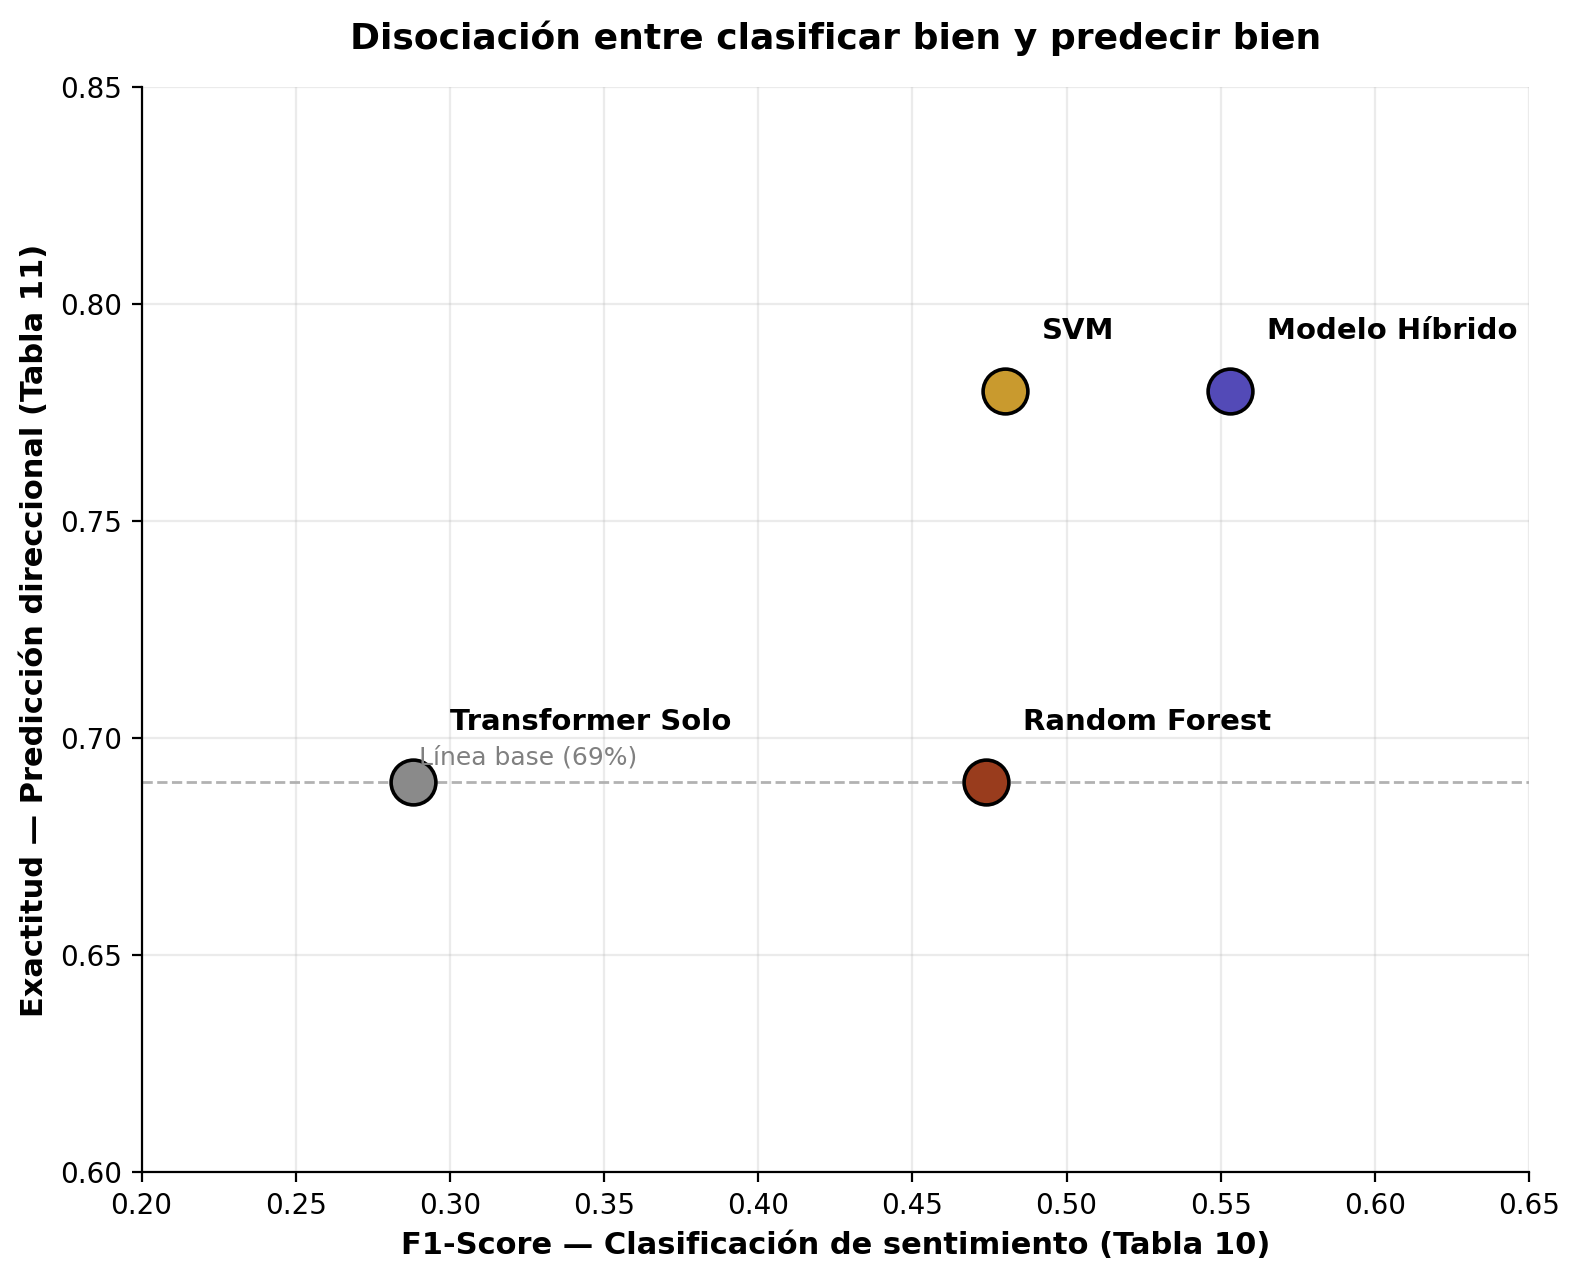

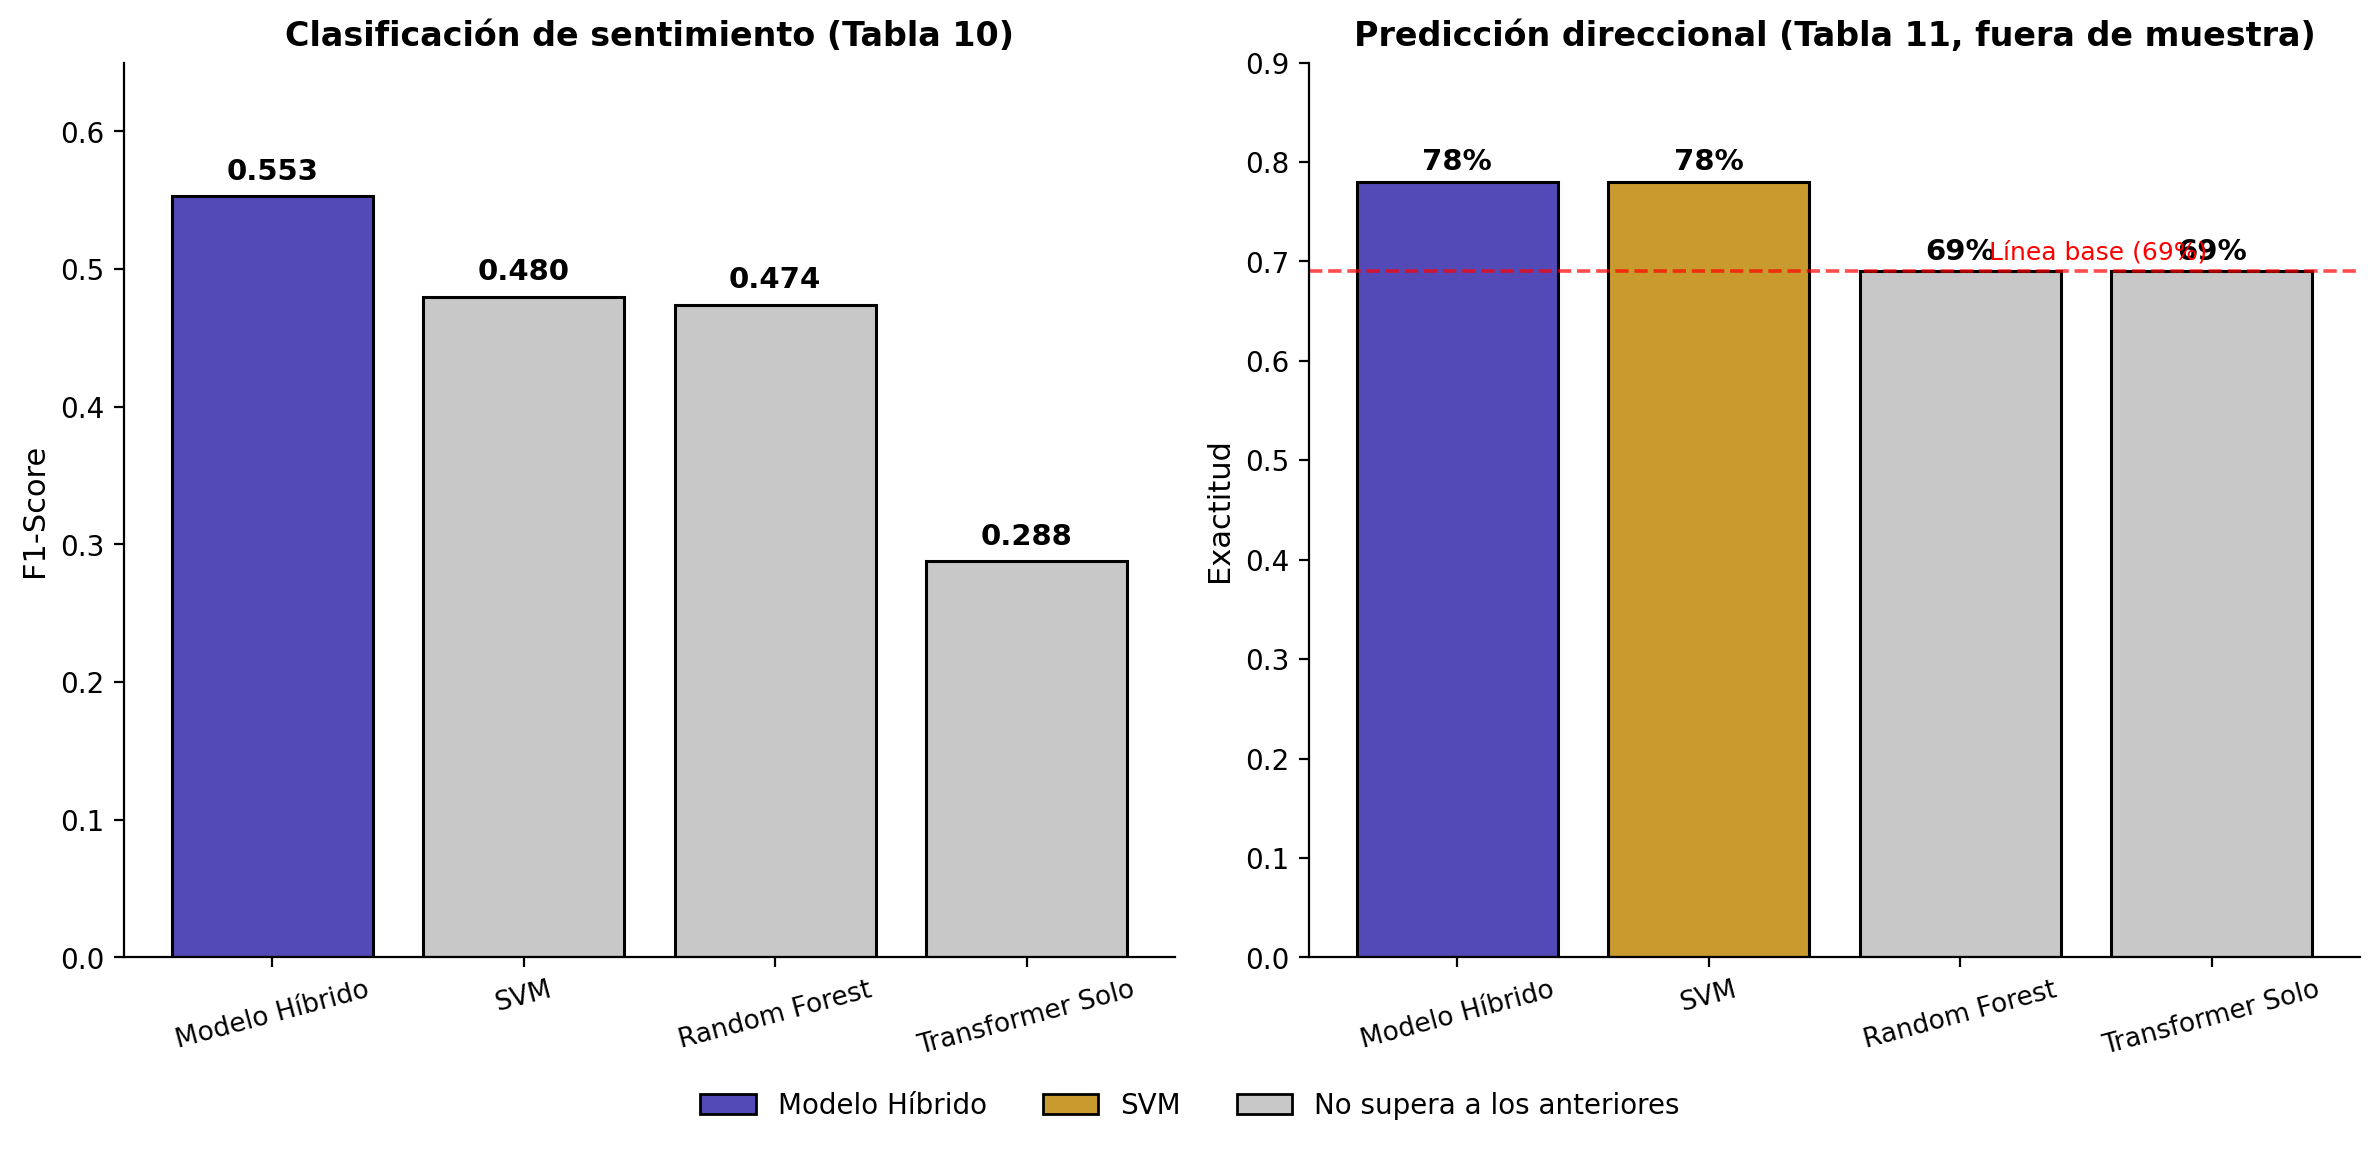

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Ambos gráficos descargados


In [1]:
"""
================================================================================
GRÁFICOS DE COMPARACIÓN DE MODELOS (reemplazo de la Figura 3)
================================================================================
Genera dos gráficos con los resultados finales ya validados de Tabla 10
(clasificación de sentimiento) y Tabla 11 (predicción direccional,
validación fuera de muestra):

  GRÁFICO 1 — Dispersión F1-Score (Tabla 10) vs. Exactitud (Tabla 11)
  Ilustra la disociación entre "clasificar bien" y "predecir bien": el
  Modelo Híbrido domina en clasificación, pero solo empata (no domina en
  solitario) en predicción direccional, donde SVM lo alcanza.

  GRÁFICO 2 — Barras de dos paneles (F1-Score | Exactitud)
  Mismos datos, en formato más directo de leer. El panel de Exactitud
  incluye la línea base (69%, predecir alza siempre) para mostrar
  visualmente que Random Forest y Transformer Solo no la superan.

No requiere subir ningún archivo: usa los valores finales ya confirmados
de Tabla 10 y Tabla 11. Si prefieres leerlos directamente de tus archivos
Tabla10_resultados.xlsx / Tabla11_resultados_CORREGIDA.xlsx en vez de
tenerlos hardcodeados, dímelo y te doy esa variante.
================================================================================
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ==============================================================================
# DATOS FINALES (Tabla 10 y Tabla 11, ya validados)
# ==============================================================================

modelos = ['Modelo Híbrido', 'SVM', 'Random Forest', 'Transformer Solo']
f1_score = [0.553, 0.480, 0.474, 0.288]        # Tabla 10
exactitud = [0.78, 0.78, 0.69, 0.69]           # Tabla 11
linea_base = 0.69

# Colores: Híbrido en color propio, SVM en color propio, RF/Transformer en gris
# (para que se noten los 2 "ganadores" de Tabla 11 sin forzar un único color)
colores = {
    'Modelo Híbrido': '#534ab7',
    'SVM': '#c99a2e',
    'Random Forest': '#993c1d',
    'Transformer Solo': '#8a8a8a',
}

# ==============================================================================
# GRÁFICO 1 — DISPERSIÓN: F1-Score vs. Exactitud
# ==============================================================================

fig, ax = plt.subplots(figsize=(8, 6.5), dpi=200)

for modelo, f1, acc in zip(modelos, f1_score, exactitud):
    ax.scatter(f1, acc, s=260, color=colores[modelo], edgecolor='black',
               linewidth=1.3, zorder=3)
    offset_x, offset_y = 0.012, 0.012
    ax.annotate(modelo, (f1, acc), xytext=(f1 + offset_x, acc + offset_y),
                fontsize=10.5, fontweight='bold')

# Líneas guía (cuadrantes) usando la línea base como referencia en Y
ax.axhline(linea_base, color='gray', linestyle='--', linewidth=1, alpha=0.6, zorder=1)
ax.text(0.29, linea_base + 0.004, 'Línea base (69%)', fontsize=9, color='gray')

ax.set_xlabel('F1-Score — Clasificación de sentimiento (Tabla 10)', fontsize=11, fontweight='bold')
ax.set_ylabel('Exactitud — Predicción direccional (Tabla 11)', fontsize=11, fontweight='bold')
ax.set_title('Disociación entre clasificar bien y predecir bien', fontsize=13, fontweight='bold', pad=14)
ax.set_xlim(0.20, 0.65)
ax.set_ylim(0.60, 0.85)
ax.grid(True, alpha=0.25)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('grafico1_dispersion_F1_vs_Exactitud.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# GRÁFICO 2 — BARRAS DE DOS PANELES
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), dpi=200)

# --- Panel izquierdo: F1-Score (Tabla 10) ---
ax1 = axes[0]
bar_colors_f1 = [colores[m] if m == 'Modelo Híbrido' else '#c9c6de' if False else colores[m]
                 for m in modelos]
# Resaltar solo al ganador (Híbrido) con color pleno, resto en gris suave
bar_colors_f1 = ['#534ab7' if m == 'Modelo Híbrido' else '#c8c8c8' for m in modelos]
bars1 = ax1.bar(modelos, f1_score, color=bar_colors_f1, edgecolor='black', linewidth=1.1)
for bar, val in zip(bars1, f1_score):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.012, f'{val:.3f}',
              ha='center', fontsize=10.5, fontweight='bold')
ax1.set_title('Clasificación de sentimiento (Tabla 10)', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1-Score', fontsize=11)
ax1.set_ylim(0, 0.65)
ax1.tick_params(axis='x', rotation=15, labelsize=9.5)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

# --- Panel derecho: Exactitud (Tabla 11) ---
ax2 = axes[1]
# Resaltar a los 2 ganadores empatados (Híbrido y SVM), resto en gris suave
bar_colors_ex = ['#534ab7' if m == 'Modelo Híbrido' else '#c99a2e' if m == 'SVM' else '#c8c8c8'
                 for m in modelos]
bars2 = ax2.bar(modelos, exactitud, color=bar_colors_ex, edgecolor='black', linewidth=1.1)
for bar, val in zip(bars2, exactitud):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.012, f'{val*100:.0f}%',
              ha='center', fontsize=10.5, fontweight='bold')
ax2.axhline(linea_base, color='red', linestyle='--', linewidth=1.3, alpha=0.7, zorder=1)
ax2.text(2.55, linea_base + 0.012, 'Línea base (69%)', fontsize=9, color='red', ha='center')
ax2.set_title('Predicción direccional (Tabla 11, fuera de muestra)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Exactitud', fontsize=11)
ax2.set_ylim(0, 0.90)
ax2.tick_params(axis='x', rotation=15, labelsize=9.5)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# Leyenda compartida
legend_elements = [
    mpatches.Patch(facecolor='#534ab7', edgecolor='black', label='Modelo Híbrido'),
    mpatches.Patch(facecolor='#c99a2e', edgecolor='black', label='SVM'),
    mpatches.Patch(facecolor='#c8c8c8', edgecolor='black', label='No supera a los anteriores'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout()
plt.savefig('grafico2_barras_F1_y_Exactitud.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# DESCARGA
# ==============================================================================
try:
    from google.colab import files
    files.download('grafico1_dispersion_F1_vs_Exactitud.png')
    files.download('grafico2_barras_F1_y_Exactitud.png')
    print("✓ Ambos gráficos descargados")
except Exception:
    print("Ejecuta esto en Google Colab para descargar automáticamente.")